
**GP AI : ANALYSE EXPLORATOIRE**

"Dans quelle mesure un modèle de classification supervisée, entraîné uniquement sur les données cliniques disponibles **avant tout test génétique**, peut-il orienter le diagnostic des troubles génétiques de l'enfant"

1. Analyse univariée (chaque variable seule)
2. Analyse bivariée (chaque variable vs `Sous-classe diagnostique`)
3. Analyse multivariée (combinaisons de variables vs `Sous-classe diagnostique`)
4. Analyse des biais (déséquilibre des classes, biais de sélection, biais liés aux valeurs manquantes imputées, risque de fuite d'information)
5. Synthèse : variables retenues pour la modélisation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.read_csv('disorders_nettoye_v2.csv')

target = 'Sous-classe diagnostique'
numeric_cols = ['Âge du patient (années)', 'Numération des globules rouges (mcL)', 'Âge de la mère',
                 'Âge du père', 'Numération des globules blancs (milliers/µL)', "Nombre d'avortements antérieurs"]
symptom_cols = ['Hypotonie musculaire', 'Retard de croissance', 'Convulsions', 'Détresse respiratoire', 'Régression neurologique']
categorical_cols = [c for c in df.columns if c not in numeric_cols + symptom_cols + [target]]

print(f"{df.shape[0]} patients, {df.shape[1]} colonnes")
print(f"{len(numeric_cols)} numériques, {len(symptom_cols)} symptômes, {len(categorical_cols)} catégorielles, 1 cible")
df.head()


18943 patients, 30 colonnes
6 numériques, 5 symptômes, 18 catégorielles, 1 cible


,Âge du patient (années),Gène maternel,Gène paternel,Numération des globules rouges (mcL),Âge de la mère,Âge du père,Fréquence respiratoire,Fréquence cardiaque,Sexe,Asphyxie à la naissance,...,Résultat du bilan sanguin,Statut du panel génétique,Nom du gène maternel,Nom du gène paternel,Hypotonie musculaire,Retard de croissance,Convulsions,Détresse respiratoire,Régression neurologique,Sous-classe diagnostique
0,2.0,Non,Non,4.760603,35.0,42.0,Normale (30-60),Normale,Inconnu,Inconnu,...,Inconnu,Non réalisé,Non réalisé,Non réalisé,1,0,1,1,0,Syndrome MELAS
1,4.0,Oui,Oui,4.910669,35.0,23.0,Tachypnée,Normale,Inconnu,Non,...,Normal,Non concluant,Non concluant,Non concluant,0,1,0,1,0,Mucoviscidose
2,6.0,Oui,Non,4.893297,41.0,22.0,Normale (30-60),Tachycardie,Inconnu,Non renseigné,...,Normal,Non réalisé,Non réalisé,Non réalisé,1,1,0,0,0,Diabète
3,12.0,Oui,Non,4.705280,21.0,42.0,Tachypnée,Normale,Masculin,Non disponible,...,Non concluant,Non réalisé,Non réalisé,Non réalisé,1,0,1,1,0,Syndrome de Leigh
4,11.0,Non,Oui,4.720703,32.0,42.0,Tachypnée,Tachycardie,Masculin,Non disponible,...,Inconnu,Réalisé,NKX2-5,Aucun,0,1,0,1,0,Cardiopathie congénitale


# 1. Analyse univariée

Chaque variable est regardée seule sans référence à la cible. 

Ca sert à repérer la forme des distributions, les valeurs aberrantes et à vérifier que la population correspond bien à ce qu'on attend (âge, répartition des sexes, etc.).

## 1.1 Répartition de la cible — Sous-classe diagnostique

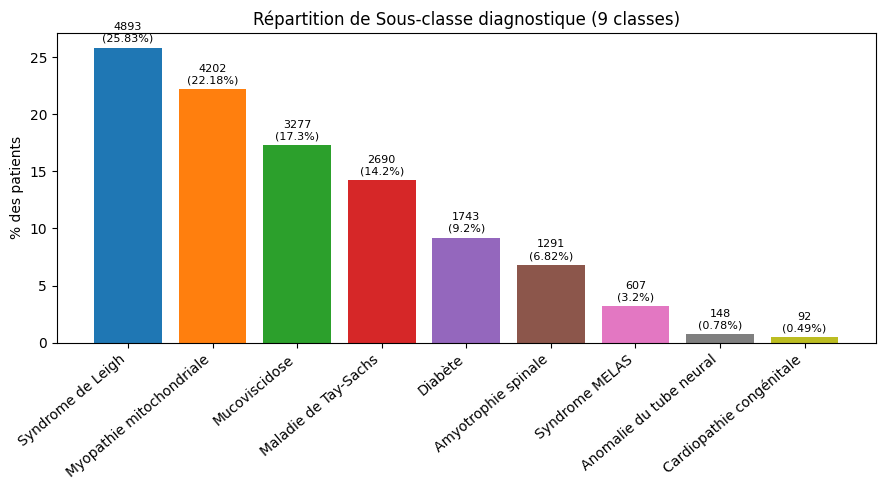

Classe la plus fréquente : Syndrome de Leigh (4893 patients)
Classe la plus rare : Cardiopathie congénitale (92 patients)
Ratio déséquilibre (max/min) : 53.2x


In [2]:
repartition = df[target].value_counts()
repartition_pct = (repartition / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
couleurs_9 = plt.cm.tab10(np.linspace(0, 1, 10))[:9]
ax.bar(repartition.index, repartition_pct.values, color=couleurs_9)
ax.set_ylabel('% des patients')
ax.set_title('Répartition de Sous-classe diagnostique (9 classes)')
plt.xticks(rotation=40, ha='right')
for i, (v, p) in enumerate(zip(repartition.values, repartition_pct.values)):
    ax.text(i, p + 0.5, f"{v}\n({p}%)", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Classe la plus fréquente : {repartition.index[0]} ({repartition.iloc[0]} patients)")
print(f"Classe la plus rare : {repartition.index[-1]} ({repartition.iloc[-1]} patients)")
print(f"Ratio déséquilibre (max/min) : {repartition.iloc[0] / repartition.iloc[-1]:.1f}x")

Ce graphique montre combien de patients il y a dans chacune des 9 maladies à prédire.

Les classes sont très déséquilibrées : le syndrome de Leigh représente à lui seul environ 1 patient sur 4 (25,8 %) alors que la cardiopathie congénitale ne compte que 92 patients (0,5 %). 

Il y a donc environ 53 fois plus de patients dans la classe la plus fréquente que dans la plus rare.

Pour conclure ce déséquilibre est important à retenir car un modèle pourrait être tenté de toujours répondre la maladie la plus fréquente pour paraître performant. 




## 1.2 Variables numériques

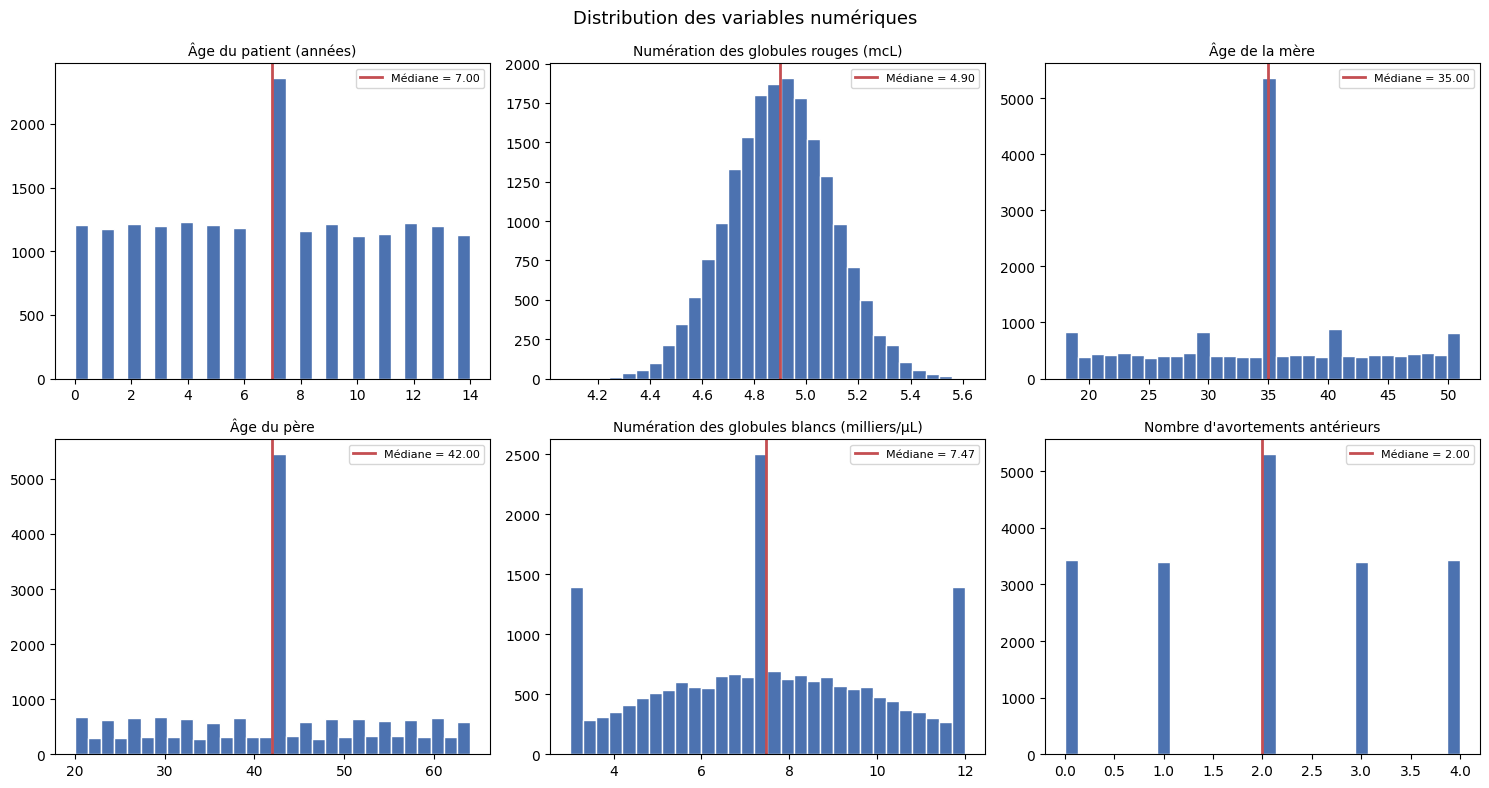

,count,mean,std,min,25%,50%,75%,max
Âge du patient (années),18943.0,6.950325,4.179697,0.000000,3.000000,7.000000,10.000000,14.000000
Numération des globules rouges (mcL),18943.0,4.899062,0.199922,4.092727,4.763367,4.899601,5.033856,5.609829
Âge de la mère,18943.0,34.660349,8.458969,18.000000,29.000000,35.000000,40.000000,51.000000
Âge du père,18943.0,41.949533,11.252986,20.000000,34.000000,42.000000,49.000000,64.000000
Numération des globules blancs (milliers/µL),18943.0,7.479823,2.526828,3.000000,5.640557,7.473316,9.282122,12.000000
Nombre d'avortements antérieurs,18943.0,1.999842,1.343595,0.000000,1.000000,2.000000,3.000000,4.000000


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=30, color="#4C72B0", edgecolor="white")
    ax.axvline(df[col].median(), color="#C44E52", linewidth=2, label=f"Médiane = {df[col].median():.2f}")
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Distribution des variables numériques", fontsize=13)
plt.tight_layout()
plt.show()

df[numeric_cols].describe().T

Chaque barre indique combien de patients ont telle valeur, la ligne rouge est la médiane (la valeur du milieu).

Les distributions sont régulières et bien étalées, sans valeur extrême isolée.

L'âge des enfants va de 0 à 14 ans (médiane 7 ans), l'âge des mères tourne autour de 35 ans et celui des pères autour de 42 ans. 

Les analyses de sang restent dans des fourchettes étroites et réalistes (globules rouges autour de 4,9, globules blancs autour de 7,5).

Pour conclure les variables numériques sont propres et bien réparties, prêtes à être utilisées.




## 1.3 Symptômes (variables binaires)

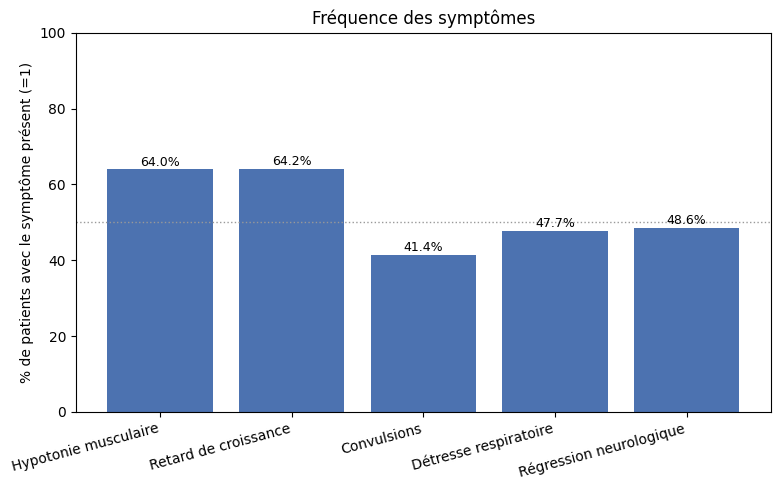

In [4]:
proportions = df[symptom_cols].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(proportions.index, proportions.values, color="#4C72B0")
ax.axhline(50, color="#999999", linestyle=":", linewidth=1)
for bar, val in zip(bars, proportions.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("% de patients avec le symptôme présent (=1)")
ax.set_ylim(0, 100)
ax.set_title("Fréquence des symptômes")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

Chaque barre montre le pourcentage de patients qui présentent le symptôme, la ligne pointillée est le repère des 50 %.

Les symptômes les plus fréquents sont le retard de croissance (64,2 %) et l'hypotonie musculaire (64,0 %), présents chez environ 2 enfants sur 3. Les convulsions (41,4 %), la détresse respiratoire (47,7 %) et la régression neurologique (48,6 %) touchent environ 1 enfant sur 2.

Pour conclure aucun symptôme n'est présent chez tout le monde ni absent chez tout le monde, ils sont donc utiles pour distinguer les maladies.


## 1.4 Variables catégorielles

Un coup d'œil sur les 18 variables catégorielles — notamment sur la proportion de `Inconnu` (valeurs imputées), qui sera reprise dans la partie biais.

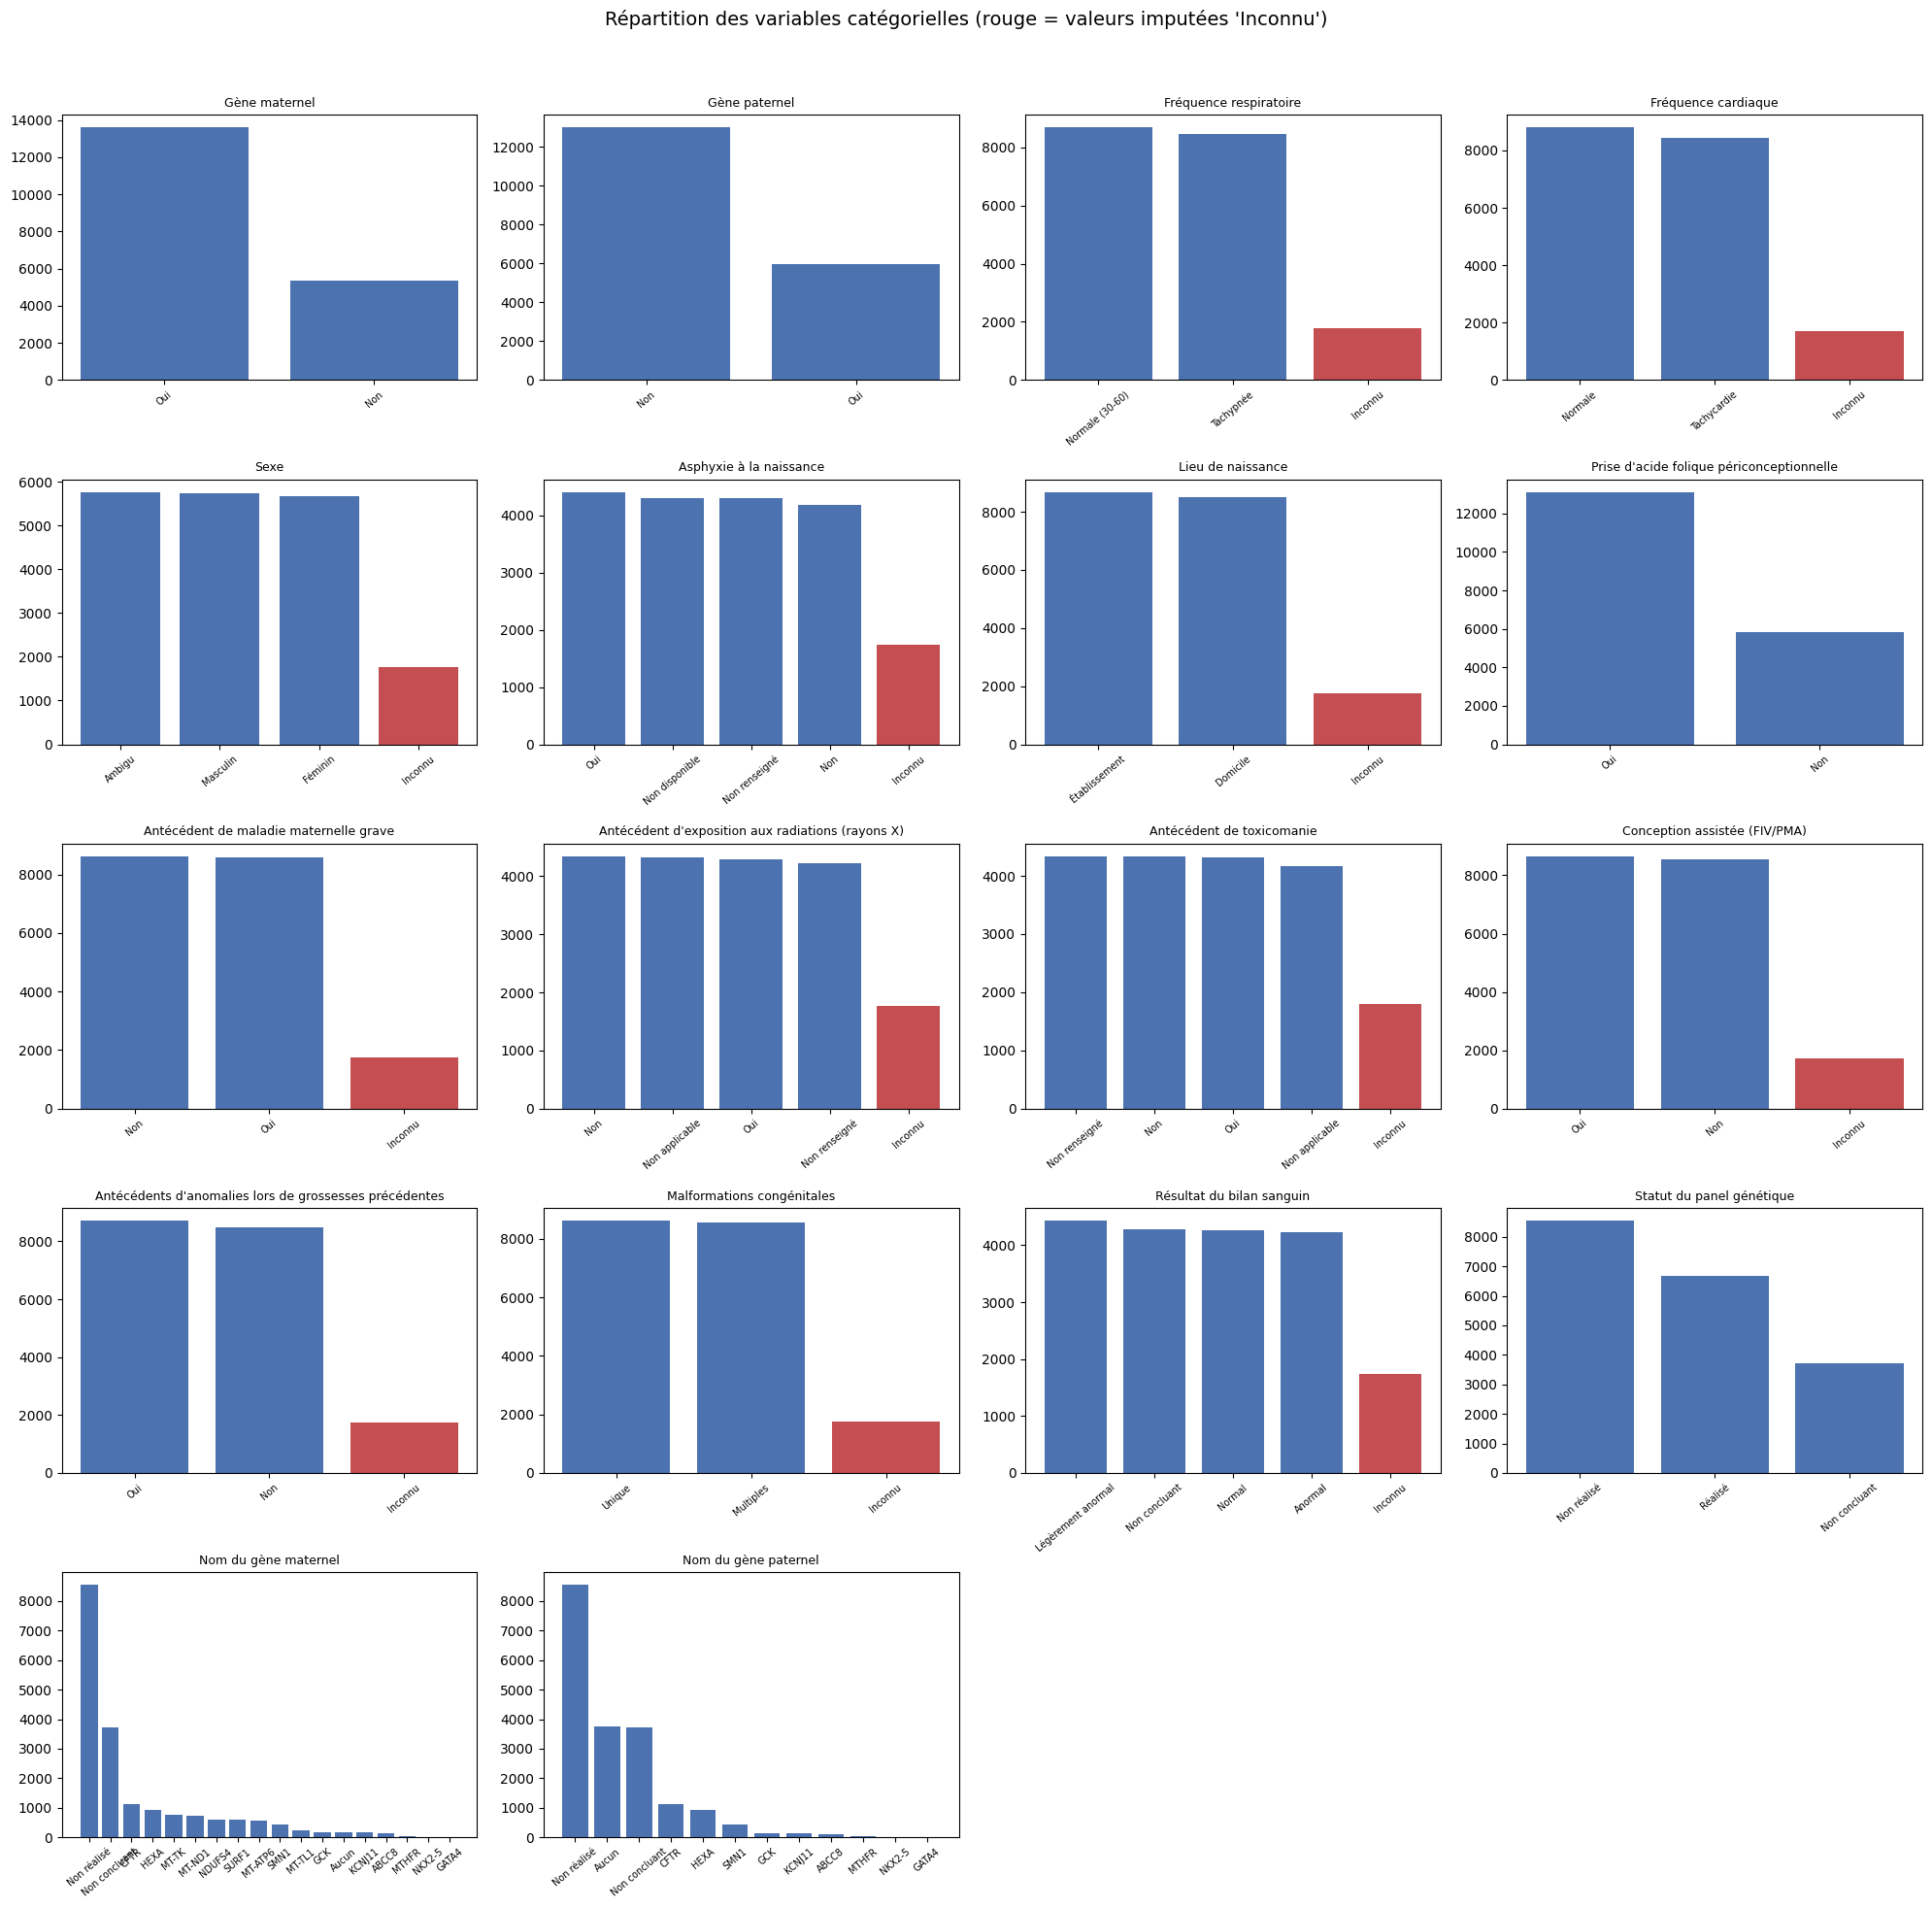

In [5]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    couleurs = ["#C44E52" if cat == 'Inconnu' else "#4C72B0" for cat in counts.index]
    ax.bar(counts.index.astype(str), counts.values, color=couleurs)
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', labelrotation=40, labelsize=7)
for ax in axes[len(categorical_cols):]:
    ax.axis('off')
fig.suptitle("Répartition des variables catégorielles (rouge = valeurs imputées 'Inconnu')", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Chaque petit graphique montre la répartition d'une variable de texte.

La plupart des variables ont une ou deux catégories dominantes, et la part d'Inconnu reste faible partout au maximum 9,5 %. 

Le remplissage des trous n'a donc pas écrasé l'information réelle.

Pour conclure ces variables restent fiables, il faudra juste garder un œil sur les valeurs Inconnu.

# 2. Analyse bivariée. Chaque variable vs Sous-classe diagnostique

## 2.1 Variables numériques vs Sous-classe diagnostique

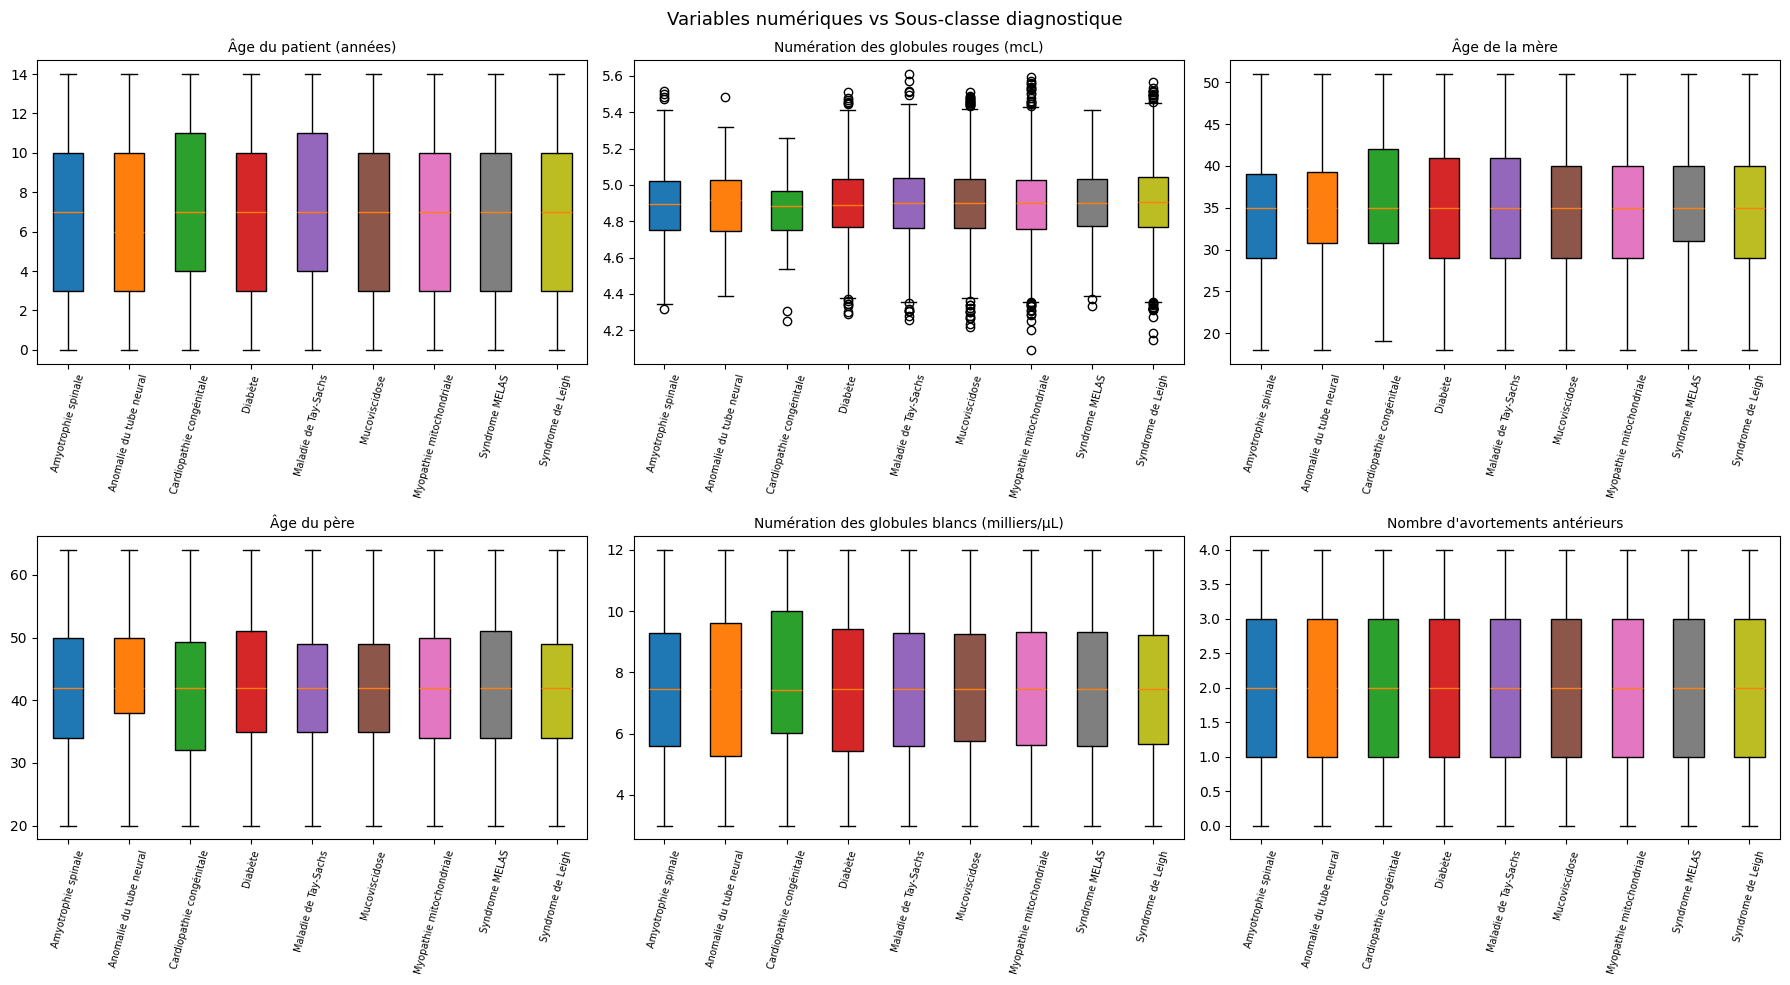

In [6]:
# Boxplots des variables numériques, groupées par Sous-classe diagnostique.
# Si les boîtes se superposent entre classes, la variable ne discrimine pas ; si elles se décalent, c'est un signal utile.
classes_subclass = sorted(df[target].unique())
palette_9 = plt.cm.tab10(np.linspace(0, 1, 10))[:9]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    data_par_classe = [df.loc[df[target] == c, col] for c in classes_subclass]
    bp = ax.boxplot(data_par_classe, patch_artist=True, tick_labels=classes_subclass)
    for patch, couleur in zip(bp['boxes'], palette_9):
        patch.set_facecolor(couleur)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', labelrotation=75, labelsize=7)
fig.suptitle("Variables numériques vs Sous-classe diagnostique", fontsize=13)
plt.tight_layout()
plt.show()

Ici on regarde chaque variable numérique séparément pour chacune des 9 maladies. L'idée est simple, si les boîtes se ressemblent d'une maladie à l'autre la variable ne permet pas de les distinguer mais si elles se décalent nettement c'est un signal utile.

On voit que les boîtes sont presque toutes au même niveau quelle que soit la maladie, autrement dit l'âge ou les analyses de sang sont à peu près les mêmes dans toutes les classes.

Pour conclure les variables numériques ne permettent pas à elles seules de reconnaître la maladie. 




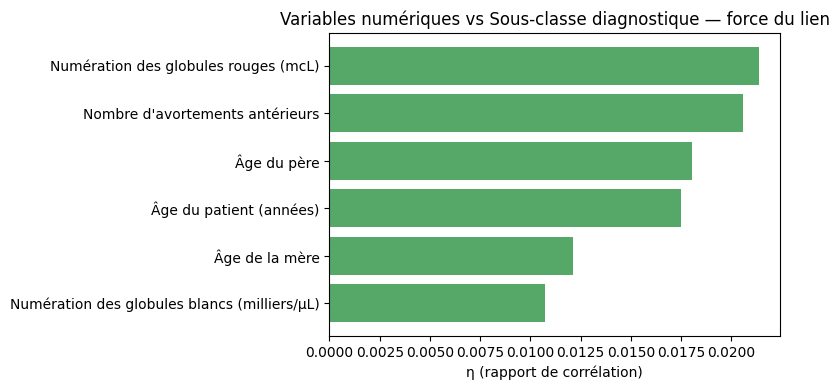

Numération des globules rouges (mcL)            0.021356
Nombre d'avortements antérieurs                 0.020593
Âge du père                                     0.018022
Âge du patient (années)                         0.017497
Âge de la mère                                  0.012109
Numération des globules blancs (milliers/µL)    0.010750
dtype: float64

In [7]:
# Rapport de corrélation (eta, η) : part de variance d'une variable numérique expliquée par la classe
# de Sous-classe diagnostique. Va de 0 (aucun lien) à 1 (lien parfait) — équivalent du V de Cramér pour du numérique.
def correlation_ratio(categories, valeurs):
    tmp = pd.DataFrame({'categorie': categories, 'valeur': valeurs})
    moyenne_globale = tmp['valeur'].mean()
    groupes = tmp.groupby('categorie')['valeur']
    ss_inter = sum(g.count() * (g.mean() - moyenne_globale) ** 2 for _, g in groupes)
    ss_totale = ((tmp['valeur'] - moyenne_globale) ** 2).sum()
    return np.sqrt(ss_inter / ss_totale)

eta_series = pd.Series({col: correlation_ratio(df[target], df[col]) for col in numeric_cols}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(eta_series.index, eta_series.values, color="#55A868")
ax.invert_yaxis()
ax.set_xlabel('η (rapport de corrélation)')
ax.set_title('Variables numériques vs Sous-classe diagnostique — force du lien')
plt.tight_layout()
plt.show()
eta_series

Ce graphique met un chiffre sur ce qu'on vient de voir. Le score êta (η) va de 0 (aucun lien) à 1 (lien parfait) et mesure à quel point une variable numérique aide à deviner la maladie.

Tous les scores sont minuscules (inférieurs à 0,03). Aucune variable numérique n'est réellement liée à la maladie.

Pour conclure les chiffres comme l'âge ou les analyses de sang seront peu utiles au modèle.


## 2.2 Matrice de corrélation (numériques + symptômes entre eux)

Sert à repérer une redondance entre variables explicatives (pas vs la cible cette fois) — deux variables très corrélées entre elles n'apportent pas d'information supplémentaire au modèle.

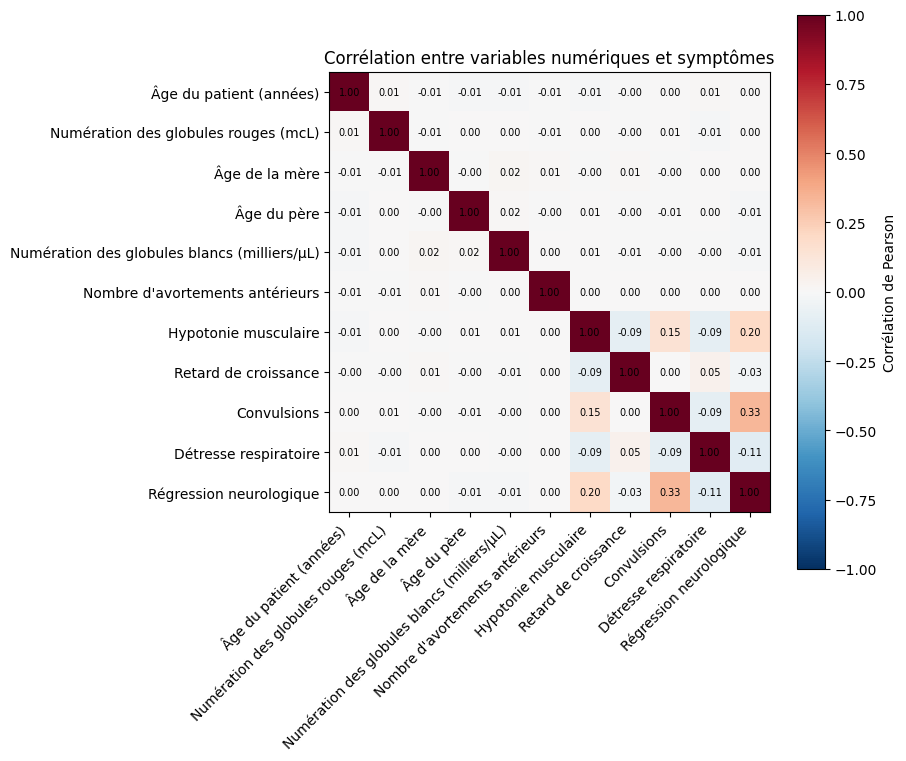

In [8]:
colonnes_etendues = numeric_cols + symptom_cols
correlation = df[colonnes_etendues].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(colonnes_etendues)))
ax.set_xticklabels(colonnes_etendues, rotation=45, ha='right')
ax.set_yticks(range(len(colonnes_etendues)))
ax.set_yticklabels(colonnes_etendues)
for i in range(len(colonnes_etendues)):
    for j in range(len(colonnes_etendues)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, label='Corrélation de Pearson')
ax.set_title('Corrélation entre variables numériques et symptômes')
plt.tight_layout()
plt.show()

Cette matrice montre à quel point les variables numériques et les symptômes évoluent ensemble. 

Un chiffre proche de 0 signifie aucun lien, proche de 1 en rouge a un lien fort.

Presque toutes les cases sont proches de 0, les variables sont indépendantes les unes des autres, il n'y a pas de doublon. 

Le lien le plus fort n'est que de 0,33 entre les convulsions et la régression neurologique, ce qui reste modéré et logique sur le plan médical (deux symptômes neurologiques).

Pour conclure il n'y a pas de redondance entre ces variables, chacune apporte sa propre information au modèle.


## 2.3 Variables catégorielles + symptômes vs Sous-classe diagnostique (V de Cramér)

Le V de Cramér mesure la force d'association entre deux variables catégorielles (0 = aucun lien, 1 = lien parfait), basé sur le test du Khi².

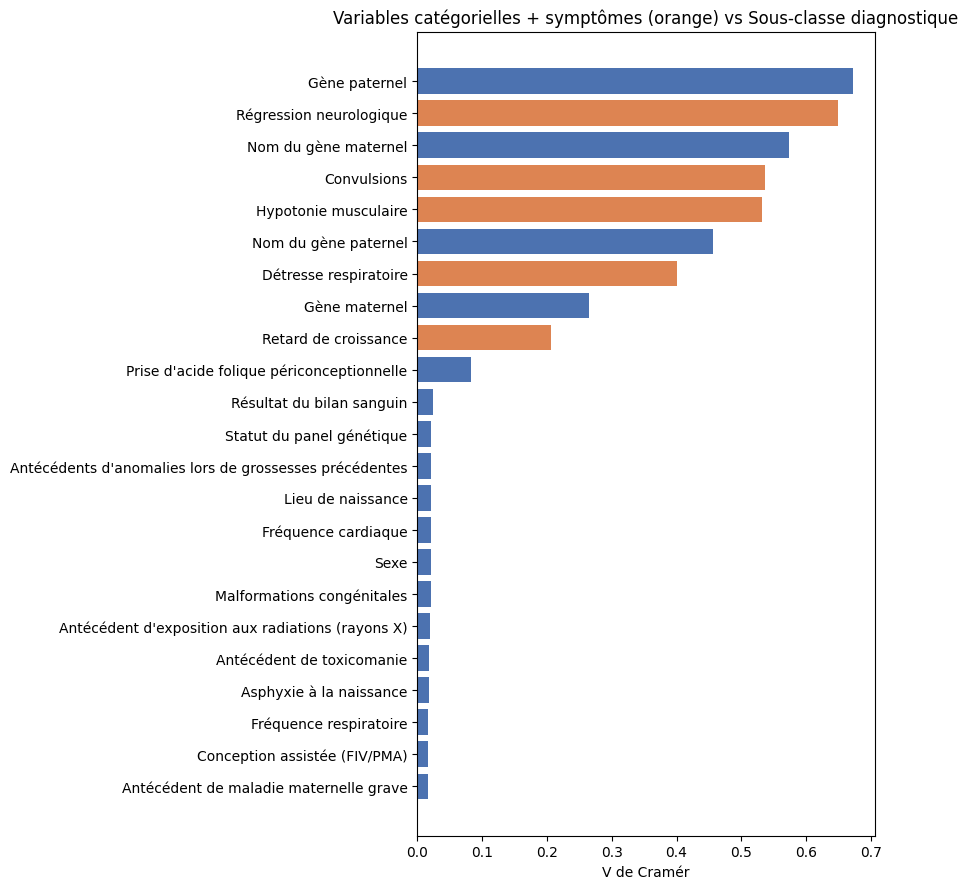

Gène paternel                                             0.671994
Régression neurologique                                   0.648920
Nom du gène maternel                                      0.572905
Convulsions                                               0.537150
Hypotonie musculaire                                      0.531714
Nom du gène paternel                                      0.455652
Détresse respiratoire                                     0.400614
Gène maternel                                             0.265335
Retard de croissance                                      0.206468
Prise d'acide folique périconceptionnelle                 0.082400
Résultat du bilan sanguin                                 0.024162
Statut du panel génétique                                 0.021995
Antécédents d'anomalies lors de grossesses précédentes    0.021968
Lieu de naissance                                         0.021902
Fréquence cardiaque                                       0.02

In [9]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    phi2 = chi2 / n
    return np.sqrt(phi2 / min(r - 1, k - 1))

toutes_les_categorielles = categorical_cols + symptom_cols
v_series = pd.Series({col: cramers_v(df[col], df[target]) for col in toutes_les_categorielles}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
couleurs_v = ["#DD8452" if c in symptom_cols else "#4C72B0" for c in v_series.index]
ax.barh(v_series.index, v_series.values, color=couleurs_v)
ax.invert_yaxis()
ax.set_xlabel('V de Cramér')
ax.set_title('Variables catégorielles + symptômes (orange) vs Sous-classe diagnostique')
plt.tight_layout()
plt.show()
v_series

Le V de Cramér mesure le lien entre une variable de texte/Symptômes et la maladie de 0 (aucun lien) à 1 (lien parfait).

Plus la barre est longue, plus la variable aide à deviner la maladie. 

Les symptômes sont en orange pour information.

On voit tout de suite que les variables les plus utiles sont les gènes et les symptômes (régression neurologique, convulsions, hypotonie musculaire) avec des scores compris entre 0,5 et 0,67.

À l'inverse des variables comme le sexe, le lieu de naissance ou la fréquence cardiaque ont des scores quasi nuls, elles n'apportent presque rien.

Pour conclure ce sont les symptômes et les informations génétiques qui portent l'information utile. 




**Point d'alerte** : `Gène paternel` (V=0,67), `Régression neurologique` (V=0,65) et `Nom du gène maternel` (V=0,57) arrivent en tête. Le score de `Gène paternel` s'explique en grande partie par la biologie : les maladies mitochondriales (Syndrome de Leigh, Myopathie mitochondriale, MELAS — plus de la moitié du dataset) se transmettent exclusivement par la mère, donc `Gène paternel = Non` y est quasi systématique — un vrai signal clinique, pas un artefact.

En revanche, `Nom du gène maternel`/`Nom du gène paternel` restent une **quasi-fuite d'information** malgré un score "seulement" modéré (0,45-0,57, pas proche de 1) : ce score modéré s'explique par le fait que 65% des lignes ont une valeur non informative (`Non réalisé`/`Non concluant`, identique pour toutes les classes) qui dilue la moyenne — mais sur les 35% de lignes où le test est concluant, la correspondance gène→maladie est quasi parfaite (`CFTR` = 100% Mucoviscidose, etc., cf. discussion précédente). `Statut du panel génétique` lui-même, en revanche, n'est **pas** associé à la cible (V=0,022) : savoir qu'un test a été fait ne dit rien sur quelle maladie, seul le résultat du test (le nom du gène) est informatif. Détaillé en section 4.5.

## 2.4 Détail des 5 variables les plus associées

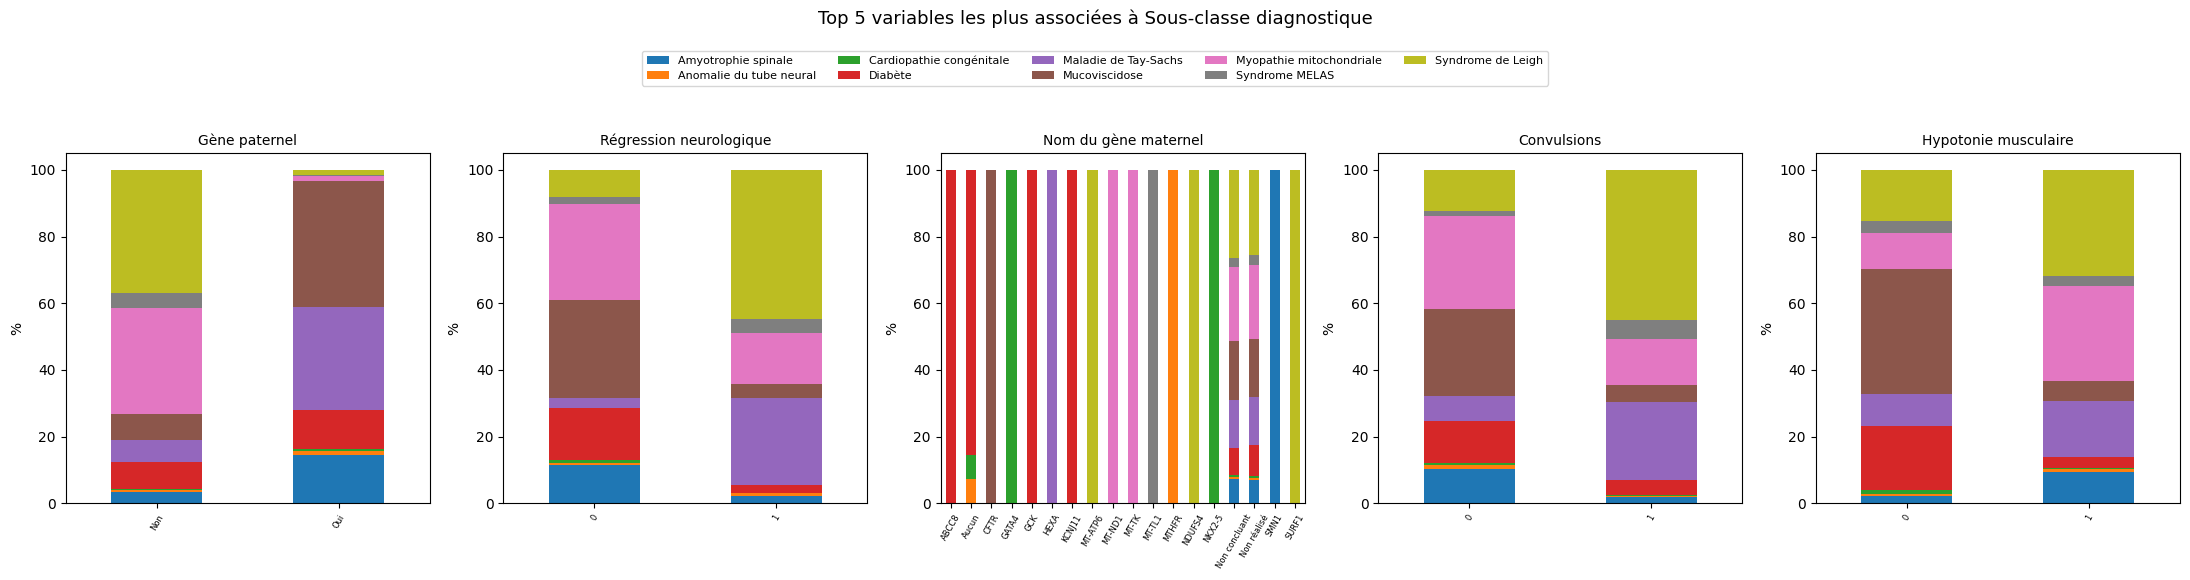

In [10]:
top_vars = v_series.index[:5]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, col in zip(axes, top_vars):
    ct = pd.crosstab(df[col], df[target], normalize='index').reindex(columns=classes_subclass) * 100
    ct.plot(kind='bar', stacked=True, ax=ax, color=palette_9, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('%')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelrotation=60, labelsize=6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=5, fontsize=8)
fig.suptitle("Top 5 variables les plus associées à Sous-classe diagnostique", fontsize=13, y=1.15)
plt.tight_layout()
plt.show()

Pour les 5 variables les plus liées à la maladie, chaque barre représente une catégorie de la variable et les couleurs montrent la répartition des 9 maladies à l'intérieur de cette catégorie.

Quand une barre est dominée par une seule couleur cela veut dire que cette catégorie correspond presque toujours à la même maladie c'est donc un indice très fort. 

On le voit surtout pour les noms de gènes où certaines valeurs pointent vers une seule maladie.




## 2.5 Signature clinique de chaque maladie (symptômes x maladies)

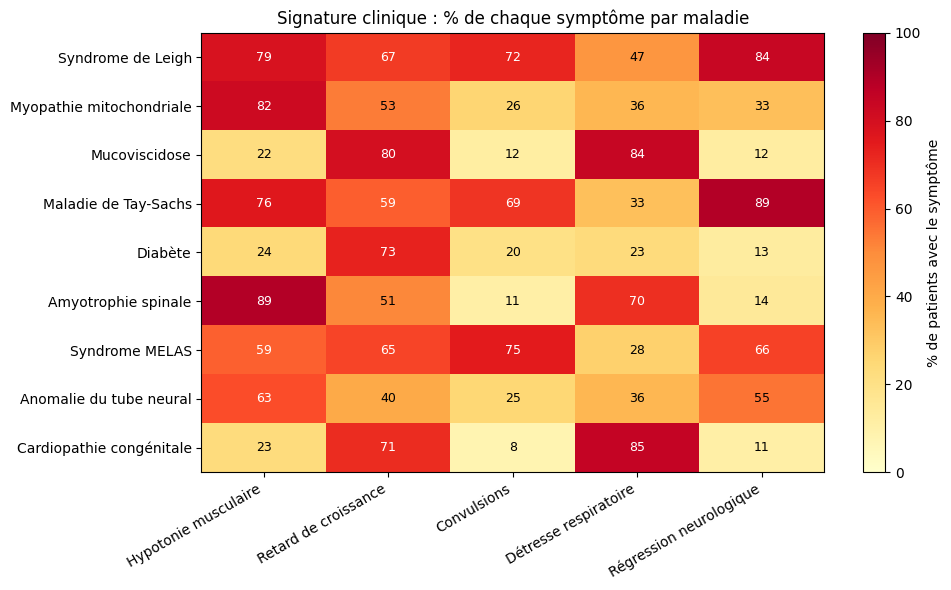

In [11]:
ordre_classes = df[target].value_counts().index.tolist()
signature = (df.groupby(target)[symptom_cols].mean() * 100).reindex(ordre_classes)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(signature.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(symptom_cols)))
ax.set_xticklabels(symptom_cols, rotation=30, ha='right')
ax.set_yticks(range(len(ordre_classes)))
ax.set_yticklabels(ordre_classes)
for i in range(len(ordre_classes)):
    for j in range(len(symptom_cols)):
        val = signature.values[i, j]
        ax.text(j, i, f"{val:.0f}", ha='center', va='center',
                color='white' if val > 55 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, label='% de patients avec le symptôme')
ax.set_title("Signature clinique : % de chaque symptôme par maladie")
plt.tight_layout()
plt.show()

Cette carte de chaleur montre pour chaque maladie (lignes) le pourcentage de patients qui présentent chaque symptôme (colonnes). 

Plus une case est rouge plus le symptôme est fréquent dans cette maladie. 

C'est le « portrait-robot » de chaque maladie.

On voit apparaître des profils très différents. 

Le syndrome de Leigh et la maladie de Tay-Sachs sont surtout neurologiques (régression neurologique 84 % et 89 %, convulsions 72 % et 69 %). 

À l'inverse la mucoviscidose et la cardiopathie congénitale sont surtout respiratoires (détresse respiratoire 84 % et 85 %) avec très peu de convulsions (12 % et 8 %). 

L'amyotrophie spinale se distingue par une hypotonie musculaire très forte (89 %). Le diabète a un profil « pauvre » sans symptôme vraiment dominant à part le retard de croissance.

Pour conclure chaque maladie a bien une combinaison de symptômes qui lui est propre, c'est exactement ce qui permet à un modèle d'orienter le diagnostic à partir des signes cliniques.


## 2.6 Nombre de symptômes par patient

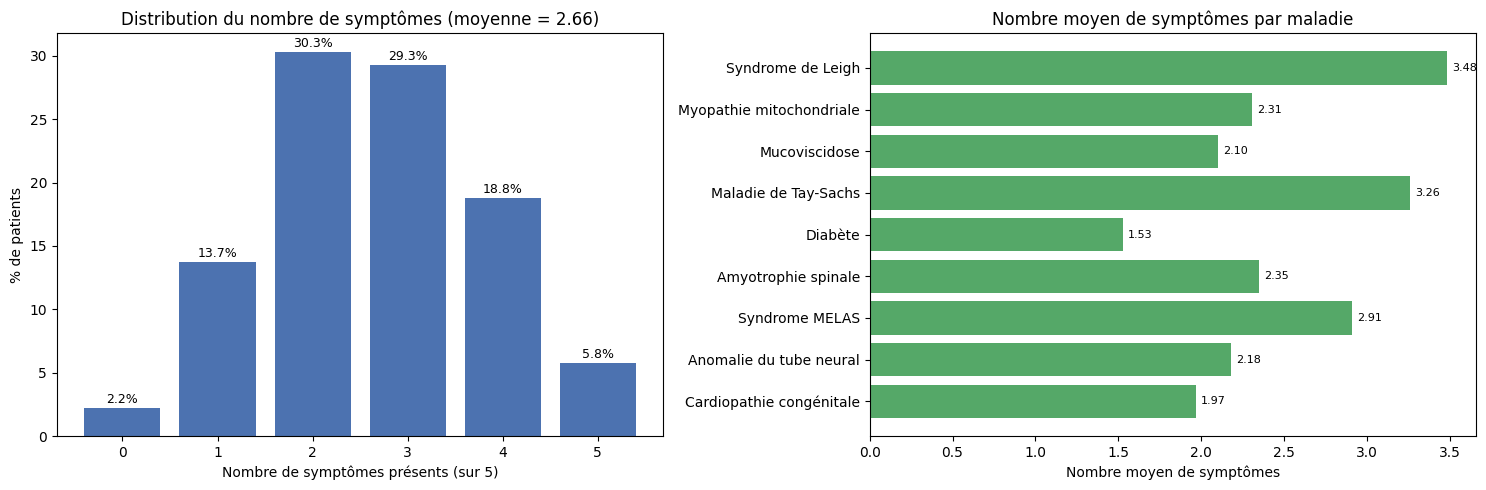

In [12]:
ordre_classes = df[target].value_counts().index.tolist()
df['nb_symptomes'] = df[symptom_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
dist = df['nb_symptomes'].value_counts(normalize=True).sort_index() * 100
axes[0].bar(dist.index, dist.values, color="#4C72B0")
for x, y in zip(dist.index, dist.values):
    axes[0].text(x, y + 0.4, f"{y:.1f}%", ha='center', fontsize=9)
axes[0].set_xlabel("Nombre de symptômes présents (sur 5)")
axes[0].set_ylabel("% de patients")
axes[0].set_title(f"Distribution du nombre de symptômes (moyenne = {df['nb_symptomes'].mean():.2f})")

moy = df.groupby(target)['nb_symptomes'].mean().reindex(ordre_classes)
axes[1].barh(moy.index, moy.values, color="#55A868")
axes[1].invert_yaxis()
axes[1].set_xlabel("Nombre moyen de symptômes")
axes[1].set_title("Nombre moyen de symptômes par maladie")
for i, v in enumerate(moy.values):
    axes[1].text(v + 0.03, i, f"{v:.2f}", va='center', fontsize=8)
plt.tight_layout()
plt.show()

À gauche, combien de symptômes chaque enfant cumule (de 0 à 5). À droite, la moyenne par maladie.

La plupart des enfants présentent 2 ou 3 symptômes (60 % à eux deux), la moyenne est de 2,66. 

Très peu n'ont aucun symptôme (2,2 %) ou les cinq (5,8 %). 

Surtout le nombre de symptômes varie selon la maladie : Le syndrome de Leigh (3,48) et la maladie de Tay-Sachs (3,26) sont « riches » en symptômes, alors que le diabète (1,53) et la cardiopathie congénitale (1,97) en présentent peu.

Pour conclure le nombre de symptômes est lui-même un indice : une maladie neurologique se manifeste par plusieurs signes à la fois, tandis qu'une maladie métabolique comme le diabète en présente peu.


# 3. Analyse multivariée : combinaison de 2 variables vs Sous-classe diagnostique

On croise 2 variables simultanément pour voir si leur combinaison sépare mieux les classes que chaque variable prise isolément. 


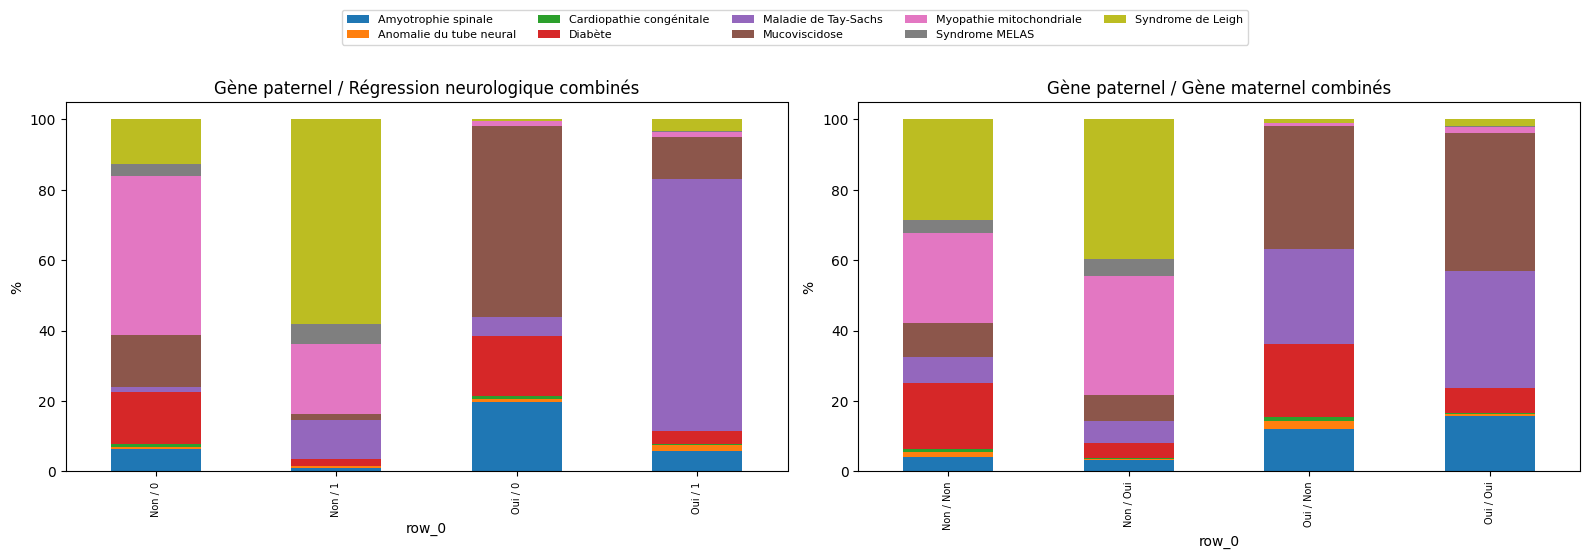

In [13]:
vars_fuite = ['Nom du gène maternel', 'Nom du gène paternel', 'Statut du panel génétique']
top_vars_cliniques = [v for v in v_series.index if v not in vars_fuite][:2]
var_a, var_b = top_vars_cliniques[0], top_vars_cliniques[1]
var_c = 'Gène maternel'

combo_ab = df[var_a].astype(str) + ' / ' + df[var_b].astype(str)
combo_ac = df[var_a].astype(str) + ' / ' + df[var_c].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ct1 = pd.crosstab(combo_ab, df[target], normalize='index').reindex(columns=classes_subclass) * 100
ct1.plot(kind='bar', stacked=True, ax=axes[0], color=palette_9, legend=False)
axes[0].set_title(f"{var_a} / {var_b} combinés")
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', labelsize=7)

ct2 = pd.crosstab(combo_ac, df[target], normalize='index').reindex(columns=classes_subclass) * 100
ct2.plot(kind='bar', stacked=True, ax=axes[1], color=palette_9, legend=False)
axes[1].set_title(f"{var_a} / {var_c} combinés")
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', labelsize=7)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

Ici il y'a deux variables en même temps pour voir si leur combinaison sépare mieux les maladies que chacune prise seule. 

Chaque barre est une combinaison (par exemple "gène paternel = Non / régression neurologique = 1") et les couleurs montrent quelles maladies s'y trouvent.

On voit que certaines combinaisons deviennent presque "mono-couleur", c'est-à-dire qu'elles pointent vers un petit groupe de maladies. 

Croiser deux indices affine donc l'orientation par rapport à une seule variable.

Pour conclure combiner plusieurs indices cliniques améliore la distinction entre maladies, ce qui est exactement ce que fera le modèle en utilisant toutes les variables ensemble.


# 4. Analyse des biais

## 4.1 Biais de déséquilibre des classes

In [14]:
print(f"Classe majoritaire : {repartition.index[0]} — {repartition.iloc[0]} patients ({repartition_pct.iloc[0]}%)")
print(f"Classe minoritaire : {repartition.index[-1]} — {repartition.iloc[-1]} patients ({repartition_pct.iloc[-1]}%)")
print(f"Un modèle qui prédirait toujours '{repartition.index[0]}' aurait déjà {repartition_pct.iloc[0]}% d'accuracy sans avoir rien appris.")
print(f"\n→ Conséquence pour la modélisation : utiliser le F1 macro (pas seulement l'accuracy),")
print("  et envisager class_weight='balanced' ou du rééchantillonnage (SMOTE) pour ne pas ignorer les classes rares")
print(f"  comme {repartition.index[-1]} ({repartition.iloc[-1]} patients) ou {repartition.index[-2]} ({repartition.iloc[-2]} patients).")

Classe majoritaire : Syndrome de Leigh — 4893 patients (25.83%)
Classe minoritaire : Cardiopathie congénitale — 92 patients (0.49%)
Un modèle qui prédirait toujours 'Syndrome de Leigh' aurait déjà 25.83% d'accuracy sans avoir rien appris.

→ Conséquence pour la modélisation : utiliser le F1 macro (pas seulement l'accuracy),
  et envisager class_weight='balanced' ou du rééchantillonnage (SMOTE) pour ne pas ignorer les classes rares
  comme Cardiopathie congénitale (92 patients) ou Anomalie du tube neural (148 patients).


## 4.2 Biais de sélection — l'absence de témoins sains

Point méthodologique important pour la portée de l'outil : Toutes les lignes du dataset correspondent à des patients avec un trouble génétique déjà diagnostiqué (Sous-classe diagnostique n'est jamais vide après nettoyage, par construction).

Il n'existe aucun patient "sain" ou "non malade" dans les données.

Conséquence directe sur la problématique ("outil d'aide au diagnostic") : Le modèle qui sera entraîné pourra seulement répondre à la question *"étant donné qu'un enfant a un trouble génétique, laquelle de ces 9 sous-classes est la plus probable ?"* — pas à la question *"cet enfant a-t-il un trouble génétique ou est-il en bonne santé ?"*. C'est un outil d'**aide à l'orientation diagnostique différentielle** entre pathologies déjà suspectées, pas un outil de dépistage en population générale. 



## 4.3 Biais lié aux valeurs manquantes imputées

Les valeurs manquantes catégorielles ont été remplacées par `Inconnu` lors du nettoyage. Si le taux de `Inconnu` d'une variable varie fortement d'une classe à l'autre, ce n'est plus un simple trou de données neutre : Le modèle pourrait apprendre à reconnaître une classe via son taux de données manquantes plutôt que via un vrai signal clinique. 

Un biais qui ne se reproduirait pas forcément à l'identique sur de nouvelles données collectées différemment.

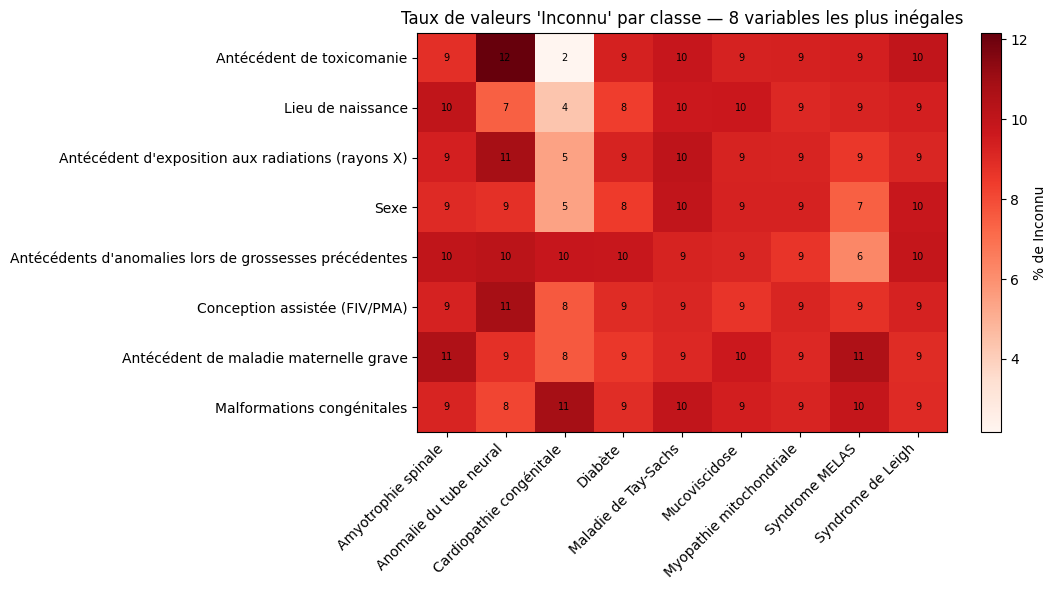

Écart max-min du taux de Inconnu entre classes (points de %) :
Antécédent de toxicomanie                                 10.0
Lieu de naissance                                          5.6
Antécédent d'exposition aux radiations (rayons X)          5.4
Sexe                                                       4.5
Antécédents d'anomalies lors de grossesses précédentes     3.9
Conception assistée (FIV/PMA)                              3.2
Antécédent de maladie maternelle grave                     2.9
Malformations congénitales                                 2.8
dtype: float64


In [15]:
cols_avec_inconnu = [c for c in categorical_cols if (df[c] == 'Inconnu').any()]

taux_inconnu_par_classe = pd.DataFrame({
    col: df.groupby(target)[col].apply(lambda s: (s == 'Inconnu').mean() * 100)
    for col in cols_avec_inconnu
})

ecart_inconnu = (taux_inconnu_par_classe.max() - taux_inconnu_par_classe.min()).sort_values(ascending=False)
top8_variables = ecart_inconnu.index[:8]

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(taux_inconnu_par_classe[top8_variables].T, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(classes_subclass)))
ax.set_xticklabels(taux_inconnu_par_classe.index, rotation=45, ha='right')
ax.set_yticks(range(len(top8_variables)))
ax.set_yticklabels(top8_variables)
for i, col in enumerate(top8_variables):
    for j, classe in enumerate(taux_inconnu_par_classe.index):
        ax.text(j, i, f"{taux_inconnu_par_classe.loc[classe, col]:.0f}", ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, label='% de Inconnu')
ax.set_title("Taux de valeurs 'Inconnu' par classe — 8 variables les plus inégales")
plt.tight_layout()
plt.show()

print("Écart max-min du taux de Inconnu entre classes (points de %) :")
print(ecart_inconnu.head(8).round(1))

Cette carte de chaleur montre, pour chaque maladie (colonnes) et chaque variable (lignes), le pourcentage de valeurs "Inconnu".

Plus une case est rouge foncé, plus il y a de données manquantes.

On cherche ici un piège, si une maladie a beaucoup plus d'Inconnu qu'une autre pour une même variable, le modèle pourrait apprendre à la reconnaître grâce à ce trou de données plutôt qu'à un vrai symptôme. 

Les écarts observés restent toutefois modérés, au maximum 10 points de pourcentage (antécédent de toxicomanie).

Pour conclure le risque existe mais reste limité, il faudra simplement rester vigilant sur les quelques variables les plus inégales.


## 4.4 Biais démographiques potentiels

Certaines variables (`Sexe`, `Lieu de naissance`) n'ont a priori pas de lien biologique direct avec un trouble génétique. 
Si elles ressortent malgré tout avec un V de Cramér élevé (section 2.3), c'est le signe d'un possible biais de collecte plutôt qu'un vrai effet clinique — à interpréter avec prudence plutôt qu'à exploiter aveuglément dans le modèle.

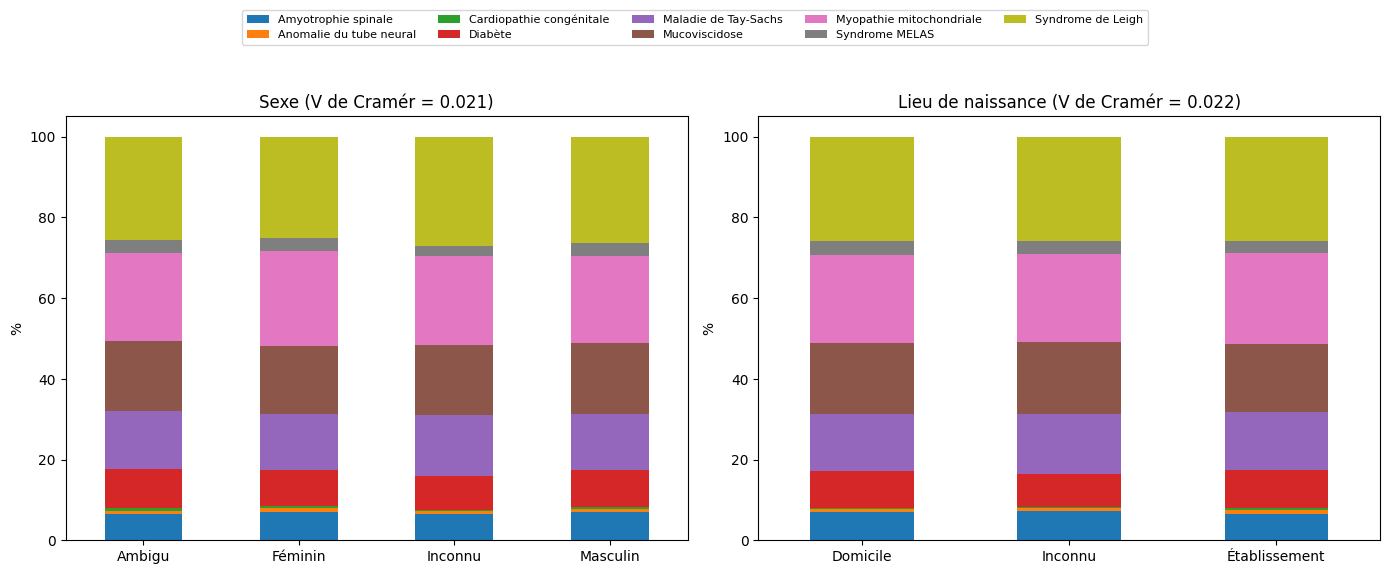

V de Cramér des variables démographiques vs les variables cliniques les plus prédictives, pour comparaison :
Sexe                       0.021
Lieu de naissance          0.022
Gène paternel              0.672
Régression neurologique    0.649
dtype: float64


In [16]:
variables_demographiques = ['Sexe', 'Lieu de naissance']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, variables_demographiques):
    ct = pd.crosstab(df[col], df[target], normalize='index').reindex(columns=classes_subclass) * 100
    ct.plot(kind='bar', stacked=True, ax=ax, color=palette_9, legend=False)
    ax.set_title(f"{col} (V de Cramér = {v_series[col]:.3f})")
    ax.set_ylabel('%')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelrotation=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

print("V de Cramér des variables démographiques vs les variables cliniques les plus prédictives, pour comparaison :")
print(v_series[variables_demographiques + list(top_vars_cliniques)].round(3))

Je vérifie ici si des caractéristiques comme le sexe ou le lieu de naissance influencent la maladie prédite. 

Les barres montrent la répartition des maladies pour chaque catégorie.

Les répartitions sont quasiment identiques d'une catégorie à l'autre, et les scores de lien (V de Cramér) sont minuscules, 0,021 pour le sexe et 0,022 pour le lieu de naissance, contre 0,67 pour le gène paternel.

Autrement dit le sexe et le lieu de naissance n'ont presque aucun effet sur la maladie.

Pour conclure c'est plutôt rassurant, le modèle ne risque pas de discriminer selon le sexe ou l'origine géographique, il s'appuiera sur des critères cliniques.


## 4.5 Risque de fuite d'information : Noms de gènes confirmés

`Nom du gène maternel` et `Nom du gène paternel` sont, dans la pratique clinique réelle, des résultats obtenus **après** qu'un trouble ait déjà été fortement suspecté chez l'enfant (on teste les parents une fois qu'une mutation candidate est trouvée chez l'enfant, pas avant). Le croisement en section 2.3 confirme que, quand le test est concluant, c'est quasiment un doublon de la cible : un gène comme `CFTR` n'apparaît que sur les lignes `Mucoviscidose`, `SMN1` que sur `Amyotrophie spinale`, etc.

`Statut du panel génétique` n'est lui-même pas concerné (V de Cramér quasi nul, 0,022) — il indique juste si un test a été fait, sans donner d'info sur la maladie. On l'exclut quand même par cohérence avec les 2 colonnes de noms de gènes, puisqu'il n'a aucune valeur prédictive propre à apporter en échange.

**Conséquence pour la modélisation** : inclure `Nom du gène maternel`/`Nom du gène paternel` comme features ferait apprendre au modèle une association quasi triviale sur les 35% de cas conclusifs, sans rien apporter sur les 65% de cas où le panel est `Non réalisé` ou `Non concluant` — qui sont justement les cas où l'outil aurait le plus d'utilité clinique. **Ces colonnes seront exclues des features du modèle prédictif**, et éventuellement réintroduites plus tard comme un module séparé (confirmation post-diagnostic) plutôt que comme aide à l'orientation initiale.

# 5. Synthèse : variables retenues pour la modélisation

Ce tableau conclut l'analyse exploratoire en transformant les constats en décisions concrètes. Chaque variable est classée selon la force de son lien avec la maladie (V de Cramér pour les variables catégorielles et les symptômes, η pour les variables numériques) et selon les risques identifiés dans la section biais.

In [17]:
fuite = ['Nom du gène maternel', 'Nom du gène paternel', 'Statut du panel génétique']

lignes = []
for var, v in v_series.items():
    if var in fuite:
        decision, motif = 'Écartée', "Fuite d'information (résultat post-diagnostic)"
    elif v >= 0.20:
        decision, motif = 'Gardée', f"Association forte avec la cible (V={v:.2f})"
    else:
        decision, motif = 'Gardée (faible)', f"Association faible (V={v:.2f}), peu discriminante"
    lignes.append({'Variable': var,
                   'Type': 'Symptôme' if var in symptom_cols else 'Catégorielle',
                   'Force du lien (V ou eta)': round(v, 3),
                   'Décision': decision, 'Justification': motif})

for var, e in eta_series.items():
    lignes.append({'Variable': var, 'Type': 'Numérique',
                   'Force du lien (V ou eta)': round(e, 3),
                   'Décision': 'Gardée (faible)',
                   'Justification': f"Lien quasi nul avec la cible (eta={e:.3f})"})

synthese = pd.DataFrame(lignes).sort_values('Force du lien (V ou eta)', ascending=False).reset_index(drop=True)
print("Variables gardées (signal fort) :", (synthese['Décision'] == 'Gardée').sum())
print("Variables gardées (faibles)     :", (synthese['Décision'] == 'Gardée (faible)').sum())
print("Variables écartées (fuite)      :", (synthese['Décision'] == 'Écartée').sum())
synthese

Variables gardées (signal fort) : 7
Variables gardées (faibles)     : 19
Variables écartées (fuite)      : 3


,Variable,Type,Force du lien (V ou eta),Décision,Justification
0,Gène paternel,Catégorielle,0.672,Gardée,Association forte avec la cible (V=0.67)
1,Régression neurologique,Symptôme,0.649,Gardée,Association forte avec la cible (V=0.65)
2,Nom du gène maternel,Catégorielle,0.573,Écartée,Fuite d'information (résultat post-diagnostic)
3,Convulsions,Symptôme,0.537,Gardée,Association forte avec la cible (V=0.54)
4,Hypotonie musculaire,Symptôme,0.532,Gardée,Association forte avec la cible (V=0.53)
5,Nom du gène paternel,Catégorielle,0.456,Écartée,Fuite d'information (résultat post-diagnostic)
6,Détresse respiratoire,Symptôme,0.401,Gardée,Association forte avec la cible (V=0.40)
7,Gène maternel,Catégorielle,0.265,Gardée,Association forte avec la cible (V=0.27)
8,Retard de croissance,Symptôme,0.206,Gardée,Association forte avec la cible (V=0.21)
9,Prise d'acide folique périconceptionnelle,Catégorielle,0.082,Gardée (faible),"Association faible (V=0.08), peu discriminante"


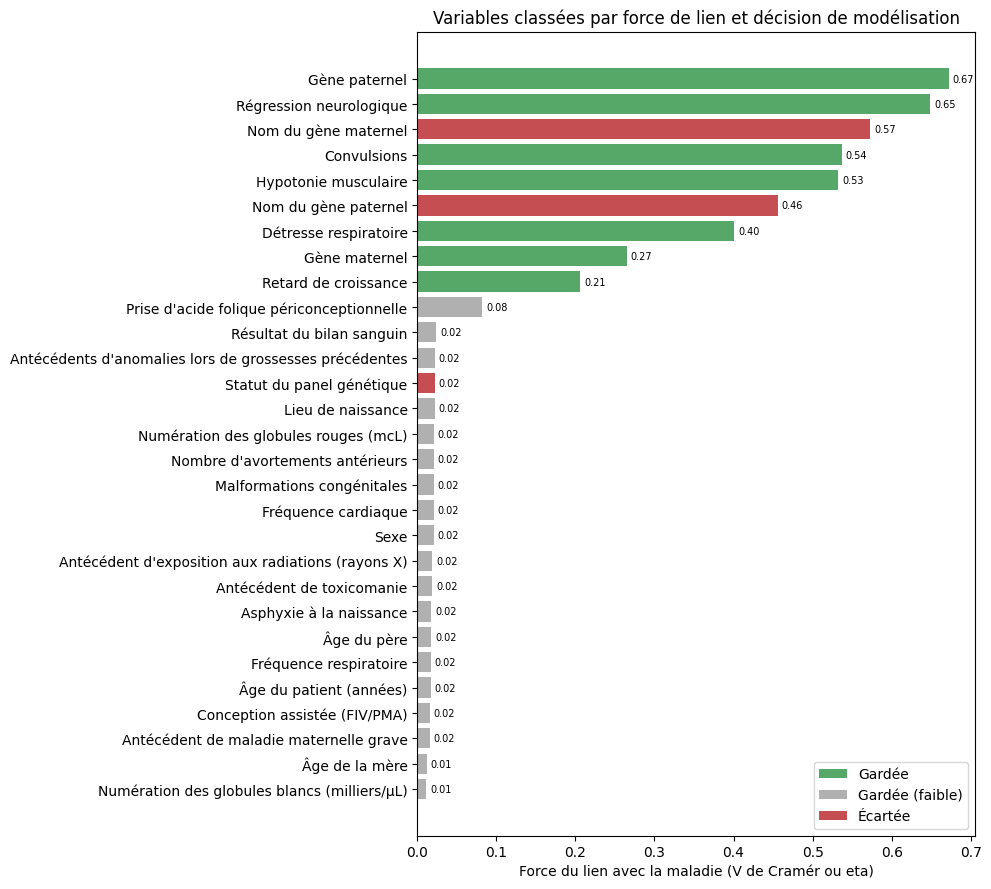

In [18]:
from matplotlib.patches import Patch

couleurs_decision = {'Gardée': '#55A868', 'Gardée (faible)': '#B0B0B0', 'Écartée': '#C44E52'}
s = synthese.sort_values('Force du lien (V ou eta)', ascending=True)
cols = [couleurs_decision[d] for d in s['Décision']]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(s['Variable'], s['Force du lien (V ou eta)'], color=cols)
for y, (v, d) in enumerate(zip(s['Force du lien (V ou eta)'], s['Décision'])):
    ax.text(v + 0.005, y, f"{v:.2f}", va='center', fontsize=7)
ax.set_xlabel('Force du lien avec la maladie (V de Cramér ou eta)')
ax.set_title("Variables classées par force de lien et décision de modélisation")
legende = [Patch(facecolor=c, label=d) for d, c in couleurs_decision.items()]
ax.legend(handles=legende, loc='lower right')
plt.tight_layout()
plt.show()

Trois variables sont écartées car elles constituent une fuite d'information : les noms de gènes (maternel et paternel) et le statut du panel génétique sont des résultats obtenus après le diagnostic, ils feraient « tricher » le modèle (voir section 4.5). Les symptômes et le type de gène transmis (Gène maternel/paternel) sont conservés comme signaux forts. Les variables numériques (âges, analyses de sang) et démographiques (sexe, lieu de naissance) sont conservées mais avec de faibles attentes, leur lien avec la maladie étant quasi nul.

Pour conclure le modèle sera entraîné principalement sur les symptômes et les informations génétiques de transmission, en excluant les variables de fuite pour rester un vrai outil d'aide au diagnostic et non un simple recopiage du résultat de laboratoire.
